# 06 — Machine Learning

Random Forest classifier on CLR-transformed genus abundances.

Notebook 05 tested genera one at a time. This tests whether genera in combination
carry more signal than any single one — gut bacteria function as interacting
communities, so a genus with a negligible solo effect may be informative alongside
others.

Three outputs:
1. AUC — how much RA vs HC signal microbiome composition carries
2. Feature importances — which genera the model relies on
3. A check of whether those agree with notebook 05

Beijing cohort (n=1,928), stratified 5-fold cross-validation.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys, os

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import roc_auc_score, roc_curve, confusion_matrix, classification_report

sys.path.insert(0, os.path.abspath('..'))
from config import PARAMS, PATHS

PROCESSED = "../data/processed/"
FIGURES   = "../results/figures/"
TABLES    = "../results/tables/"

clr_df = pd.read_csv(PROCESSED + "genus_clr.csv", index_col="sample_id")
meta   = pd.read_csv(PROCESSED + "metadata.csv",  index_col="sample_id")

beijing = meta.index[meta["location"] == "Beijing"]
X = clr_df.loc[beijing]
y = (meta.loc[beijing, "disease_status"] == "RA").astype(int)

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100

print(f"Feature matrix: {X.shape}")
print(f"Labels: {y.sum()} RA, {(y==0).sum()} HC")
print(f"Class balance: {y.mean():.1%} positive")

Feature matrix: (1928, 128)
Labels: 819 RA, 1109 HC
Class balance: 42.5% positive


## Cross-validated Random Forest

Stratified 5-fold: each fold preserves the RA/HC ratio. Report AUC per fold
with mean ± SD, not a single train/test split — one split gives a number with
no sense of how stable it is.

In [4]:
rf = RandomForestClassifier(
    n_estimators=500,
    max_features="sqrt",
    min_samples_leaf=5,
    random_state=PARAMS["random_state"],
    n_jobs=-1
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=PARAMS["random_state"])

fold_aucs = []
for train_idx, test_idx in cv.split(X, y):
    rf.fit(X.iloc[train_idx], y.iloc[train_idx])
    probs = rf.predict_proba(X.iloc[test_idx])[:, 1]
    fold_aucs.append(roc_auc_score(y.iloc[test_idx], probs))

print("AUC per fold:", [f"{a:.3f}" for a in fold_aucs])
print(f"Mean AUC: {np.mean(fold_aucs):.3f} ± {np.std(fold_aucs):.3f}")

AUC per fold: ['0.755', '0.779', '0.814', '0.757', '0.760']
Mean AUC: 0.773 ± 0.022


In [5]:
# Fit on all Beijing data for importances
rf.fit(X, y)

imp = pd.DataFrame({
    "genus": X.columns,
    "importance": rf.feature_importances_
}).sort_values("importance", ascending=False)

print("Top 20 by Random Forest importance:")
print(imp.head(20).round(4).to_string(index=False))

# Cross-check against differential abundance
da = pd.read_csv(TABLES + "differential_abundance_beijing.csv")
merged = imp.merge(da[["genus", "cliffs_d", "q_value", "effect"]], on="genus")

top20_rf = set(imp.head(20).genus)
top20_da = set(da.reindex(da.cliffs_d.abs().sort_values(ascending=False).index).head(20).genus)

print(f"\nOverlap between top 20 RF and top 20 differential abundance: {len(top20_rf & top20_da)}/20")
print(f"In RF top 20 but not DA top 20: {sorted(top20_rf - top20_da)}")

Top 20 by Random Forest importance:
                       genus  importance
                  Klebsiella      0.0284
                   Bilophila      0.0215
                 Veillonella      0.0211
                     Blautia      0.0201
Lachnospiraceae NC2004 group      0.0173
 [Ruminococcus] gnavus group      0.0169
             Subdoligranulum      0.0159
              Parasutterella      0.0156
           Lachnoclostridium      0.0156
            Terrisporobacter      0.0152
                Anaerostipes      0.0151
              Ruminococcus 2      0.0142
 Clostridium sensu stricto 1      0.0141
        Escherichia-Shigella      0.0139
             Intestinibacter      0.0139
  [Eubacterium] hallii group      0.0131
                 Lactococcus      0.0130
      Erysipelatoclostridium      0.0126
                Enterobacter      0.0125
             Bifidobacterium      0.0125

Overlap between top 20 RF and top 20 differential abundance: 7/20
In RF top 20 but not DA top 20: ['An

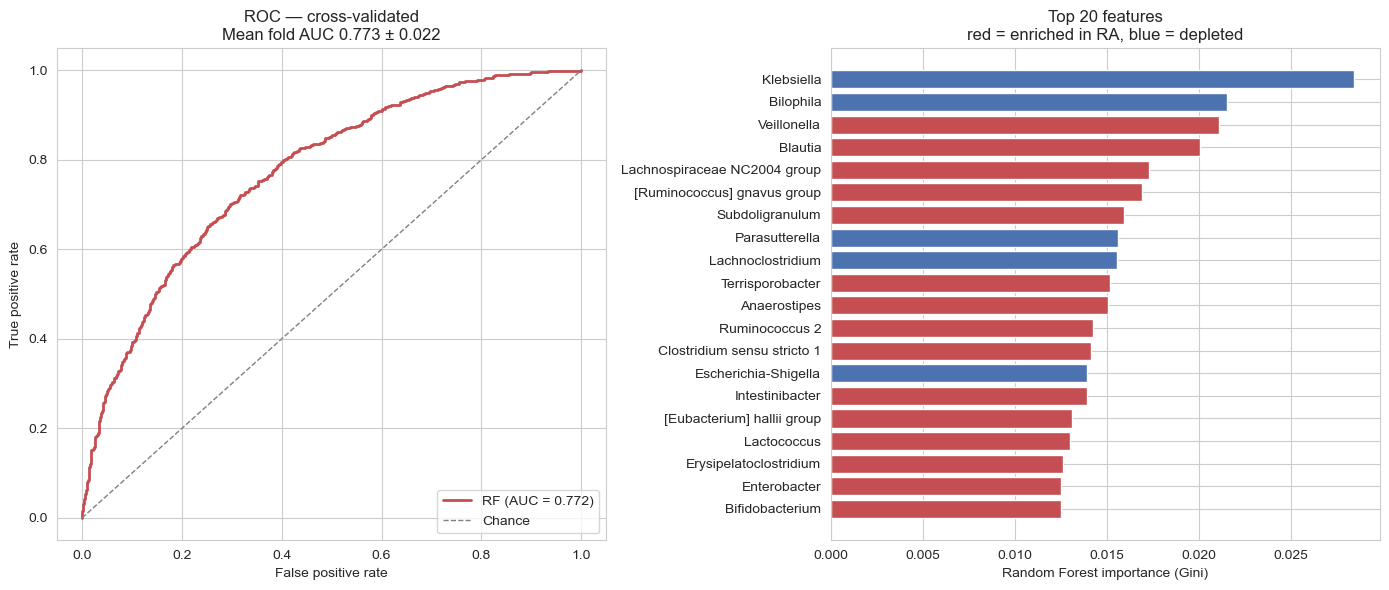

In [6]:
probs = cross_val_predict(rf, X, y, cv=cv, method="predict_proba")[:, 1]
fpr, tpr, _ = roc_curve(y, probs)
auc_overall = roc_auc_score(y, probs)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].plot(fpr, tpr, lw=2, color="#C44E52",
             label=f"RF (AUC = {auc_overall:.3f})")
axes[0].plot([0,1],[0,1], ls="--", c="grey", lw=1, label="Chance")
axes[0].set_xlabel("False positive rate")
axes[0].set_ylabel("True positive rate")
axes[0].set_title(f"ROC — cross-validated\nMean fold AUC {np.mean(fold_aucs):.3f} ± {np.std(fold_aucs):.3f}")
axes[0].legend(loc="lower right")

top = merged.head(20).sort_values("importance")
colours = ["#C44E52" if d > 0 else "#4C72B0" for d in top.cliffs_d]
axes[1].barh(top.genus, top.importance, color=colours)
axes[1].set_xlabel("Random Forest importance (Gini)")
axes[1].set_title("Top 20 features\nred = enriched in RA, blue = depleted")

plt.tight_layout()
plt.savefig(FIGURES + "ml_results.png", dpi=200, bbox_inches="tight")
plt.show()

merged.to_csv(TABLES + "rf_importances.csv", index=False)

In [9]:
import shap

# TreeExplainer is exact for tree models, no sampling approximation
explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X)

# Binary classifier returns values for both classes; take the positive class
if isinstance(shap_values, list):
    sv = shap_values[1]
else:
    sv = shap_values[:, :, 1] if shap_values.ndim == 3 else shap_values

print(f"SHAP values shape: {sv.shape}")

SHAP values shape: (1928, 128)


In [10]:
# Mean |SHAP| per genus — the SHAP equivalent of a global importance ranking
shap_imp = pd.DataFrame({
    "genus": X.columns,
    "mean_abs_shap": np.abs(sv).mean(axis=0),
    "mean_shap": sv.mean(axis=0)          # signed: direction of average effect
}).sort_values("mean_abs_shap", ascending=False)

# Merge against Gini and differential abundance
comparison = (shap_imp
    .merge(imp.rename(columns={"importance": "gini"}), on="genus")
    .merge(da[["genus", "cliffs_d", "q_value", "effect"]], on="genus"))

comparison["rank_shap"] = comparison.mean_abs_shap.rank(ascending=False)
comparison["rank_gini"] = comparison.gini.rank(ascending=False)
comparison["rank_shift"] = comparison.rank_gini - comparison.rank_shap

print("TOP 20 BY SHAP")
print(comparison.head(20)[
    ["genus", "mean_abs_shap", "rank_shap", "rank_gini", "cliffs_d", "effect"]
].round(4).to_string(index=False))

# The key test: does SHAP agree with differential abundance better than Gini did?
top20_shap = set(comparison.head(20).genus)
top20_gini = set(imp.head(20).genus)
top20_da   = set(da.reindex(da.cliffs_d.abs().sort_values(ascending=False).index).head(20).genus)

print(f"\nOverlap with differential abundance top 20:")
print(f"  Gini: {len(top20_gini & top20_da)}/20")
print(f"  SHAP: {len(top20_shap & top20_da)}/20")

# Did the oral taxa recover?
oral = ["Veillonella", "Rothia", "Granulicatella", "Haemophilus", "Staphylococcus"]
print(f"\nOral taxa rankings (SHAP vs Gini):")
print(comparison[comparison.genus.isin(oral)][
    ["genus", "rank_shap", "rank_gini", "rank_shift", "cliffs_d"]
].round(1).to_string(index=False))

comparison.to_csv(TABLES + "shap_vs_gini.csv", index=False)

TOP 20 BY SHAP
                       genus  mean_abs_shap  rank_shap  rank_gini  cliffs_d     effect
                  Klebsiella         0.0249        1.0        1.0   -0.1026 negligible
                 Veillonella         0.0177        2.0        3.0    0.2741      small
                   Bilophila         0.0162        3.0        2.0   -0.2207      small
Lachnospiraceae NC2004 group         0.0131        4.0        5.0    0.2431      small
                     Blautia         0.0118        5.0        4.0    0.2218      small
            Terrisporobacter         0.0111        6.0       10.0    0.2683      small
 [Ruminococcus] gnavus group         0.0107        7.0        6.0    0.2510      small
             Subdoligranulum         0.0103        8.0        7.0    0.0405 negligible
              Parasutterella         0.0100        9.0        8.0   -0.1268 negligible
           Lachnoclostridium         0.0090       10.0        9.0   -0.0355 negligible
                Anaerostipes

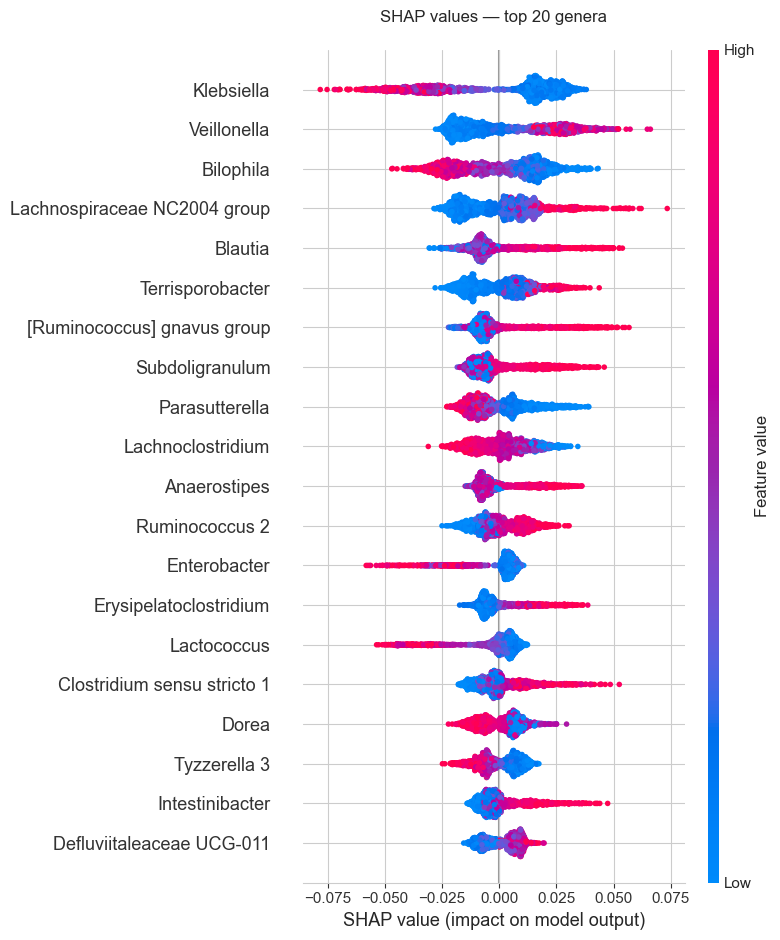

In [11]:
shap.summary_plot(sv, X, max_display=20, show=False)
plt.title("SHAP values — top 20 genera", pad=20)
plt.tight_layout()
plt.savefig(FIGURES + "shap_summary.png", dpi=200, bbox_inches="tight")
plt.show()

In [ ]:
-b